# traQmania 01 — The racing environment

**traQmania** is a Trackmania-style racing game in which a 4-qubit variational
quantum circuit learns to drive. This notebook series builds the whole thing up
from scratch:

1. **The racing environment** (this notebook) — track, car physics, lidar, reward
2. [Q-learning from scratch](02_q_learning_from_scratch.ipynb) — a classical baseline agent
3. [Quantum circuits as Q-functions](03_quantum_circuits_as_q_functions.ipynb) — the variational circuit
4. [Training the quantum driver](04_training_the_quantum_driver.ipynb) — quantum vs classical, with data
5. [Real quantum hardware](05_real_quantum_hardware.ipynb) — shots, noise, and IBM Quantum devices

Before any quantum circuit shows up, we need to understand the *game* the agent
plays. Everything here is plain numpy.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import matplotlib.pyplot as plt
import numpy as np

## Tracks

A track is a closed-loop **centerline** (a list of 2D points loaded from JSON),
resampled to uniform arc-length spacing. The racing surface extends
`half_width` to each side of the centerline, so the two **boundaries** are the
centerline shifted along its unit normals. **Checkpoints** are fractions of the
lap distance; crossing one during a lap pays a small reward bonus.

traQmania ships three tracks: `oval` (easy), `chicane` (left-right flick), and
`gp` (a longer circuit with a hairpin).

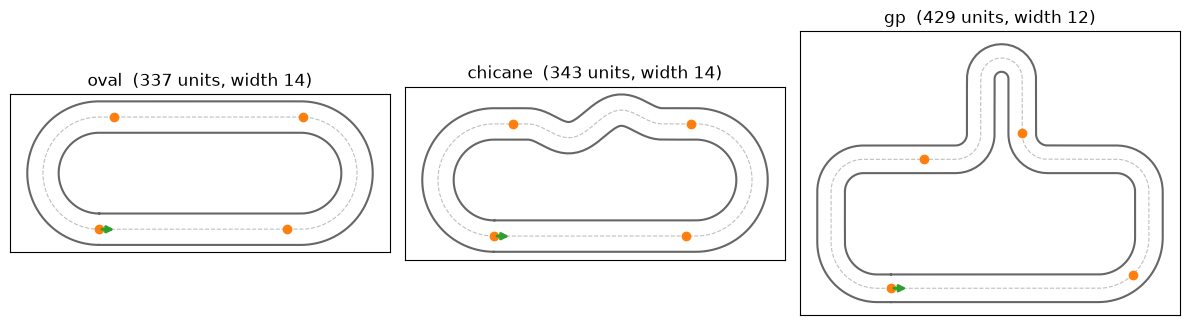

In [2]:
from traqmania.env.track import Track


def draw_track(ax, track, title=None):
    cl, hw = track.centerline, track.half_width
    for sign in (+1.0, -1.0):
        b = cl + sign * hw * track.normals
        b = np.vstack([b, b[:1]])  # close the loop
        ax.plot(b[:, 0], b[:, 1], color="0.4", lw=1.5)
    closed = np.vstack([cl, cl[:1]])
    ax.plot(closed[:, 0], closed[:, 1], ls="--", color="0.75", lw=0.8)
    for frac in track.checkpoints:
        p = cl[int(frac * len(cl)) % len(cl)]
        ax.plot(*p, "o", color="tab:orange", ms=6)
    x0, y0, h0 = track.start_pose()
    ax.annotate("", xy=(x0 + 8 * np.cos(h0), y0 + 8 * np.sin(h0)), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="tab:green", lw=2))
    ax.set_aspect("equal")
    ax.set_title(title or track.name)
    ax.set_xticks([]), ax.set_yticks([])


fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, ("oval", "chicane", "gp"), strict=True):
    t = Track.load(name)
    draw_track(ax, t, f"{name}  ({t.total_length:.0f} units, width {2 * t.half_width:.0f})")
plt.tight_layout()
plt.show()

Orange dots are checkpoints, the green arrow is the start pose (direction of
travel). The dashed line is the centerline the reward is measured along.

## Car physics: why you must brake for hairpins

The car is a simple kinematic model — state `[x, y, heading, speed]` stepped at
60 Hz. Throttle accelerates, braking and drag decelerate, and steering turns
the heading at a rate

$$\dot\theta = \mathrm{steer} \cdot k_\mathrm{steer} \cdot f(v),$$

where the **steering falloff** $f(v)$ peaks at `v_turn` and decays at higher
speed: a parked car can't turn at all, and a flat-out car *understeers*. The
turning radius is $r(v) = v \,/\, (k_\mathrm{steer} f(v))$ — and it grows
quadratically with speed.

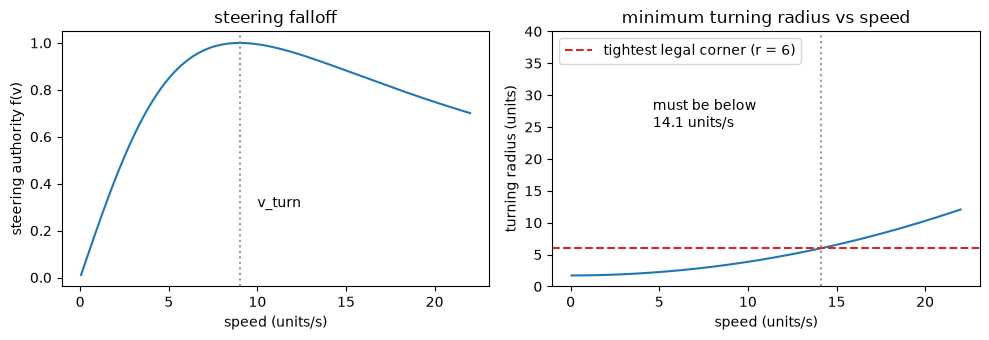

top speed 22.0 units/s -> turning radius 12.1 units
a 6-unit hairpin is only drivable below 14.1 units/s


In [3]:
from traqmania.config import load_config
from traqmania.env.car import CarPhysics
from traqmania.env.track import MIN_CORNER_RADIUS

config = load_config()
car = CarPhysics(config["physics"])

v = np.linspace(0.05, car.v_max, 300)
falloff = car.steer_falloff(v)
radius = v / (car.k_steer * falloff)
# r(v) = (v_turn^2 + v^2) / (2 k_steer v_turn); solve r(v) = R for v:
v_crit = np.sqrt(2 * MIN_CORNER_RADIUS * car.k_steer * car.v_turn - car.v_turn**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(v, falloff)
ax1.axvline(car.v_turn, color="0.6", ls=":")
ax1.annotate("v_turn", (car.v_turn, 0.35), xytext=(car.v_turn + 1, 0.3))
ax1.set(xlabel="speed (units/s)", ylabel="steering authority f(v)",
        title="steering falloff")

ax2.plot(v, radius)
ax2.axhline(MIN_CORNER_RADIUS, color="tab:red", ls="--",
            label=f"tightest legal corner (r = {MIN_CORNER_RADIUS:.0f})")
ax2.axvline(v_crit, color="0.6", ls=":")
ax2.annotate(f"must be below\n{v_crit:.1f} units/s", (v_crit, 22),
             xytext=(v_crit - 9.5, 25))
ax2.set(xlabel="speed (units/s)", ylabel="turning radius (units)",
        title="minimum turning radius vs speed", ylim=(0, 40))
ax2.legend()
plt.tight_layout()
plt.show()
print(f"top speed {car.v_max} units/s -> turning radius {radius[-1]:.1f} units")
print(f"a {MIN_CORNER_RADIUS:.0f}-unit hairpin is only drivable below {v_crit:.1f} units/s")

At top speed the car needs a corner far wider than the tightest one a track may
contain — so a flat-out driver *will* fly off at a hairpin. Any successful
policy has to learn the one non-obvious skill of this game: **hit the brake
action before tight corners**, even though braking looks locally bad for a
progress-based reward.

## What the agent sees: lidar

The agent does not get coordinates or a map. Its observation is four numbers in
$[0, 1]$:

| feature | meaning |
|---|---|
| `ray(-60°)` | distance to the boundary, 60° to the left of heading |
| `ray(0°)` | distance straight ahead |
| `ray(+60°)` | distance 60° to the right |
| `v / v_max` | normalized speed |

Rays are capped at `ray_max_dist` (30 units) and normalized. Four floats in,
one steering decision out — this small observation is what lets a 4-qubit
circuit play at all (one feature per qubit).

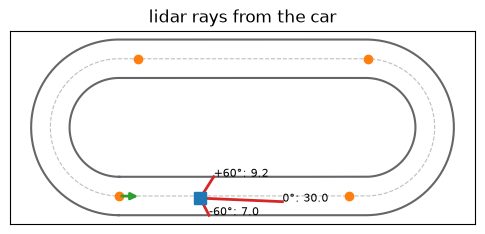

observation: [0.234 1.    0.307 0.761]  = [ray(-60°), ray(0°), ray(+60°), v/v_max]


In [4]:
from traqmania.env.racing_env import RacingEnv

track = Track.load("oval")
env = RacingEnv(track, config, n_envs=1, seed=0)
obs = env.reset()
for _ in range(30):  # roll forward under full throttle so the pose is interesting
    obs, *_ = env.step(np.array([1]))

x, y, heading, v = env.state[0]
angles = heading + env.ray_angles
dists = track.raycast(np.repeat([[x, y]], len(angles), axis=0), angles, env.ray_max_dist)

fig, ax = plt.subplots(figsize=(6, 5))
draw_track(ax, track)
for ang, d, lbl in zip(angles, dists, ("-60°", "0°", "+60°"), strict=True):
    ax.plot([x, x + d * np.cos(ang)], [y, y + d * np.sin(ang)], color="tab:red", lw=2)
    ax.annotate(f"{lbl}: {d:.1f}", (x + d * np.cos(ang), y + d * np.sin(ang)), fontsize=8)
ax.plot(x, y, "s", color="tab:blue", ms=8)
ax.set_title("lidar rays from the car")
plt.show()
print("observation:", np.round(obs[0], 3), " = [ray(-60°), ray(0°), ray(+60°), v/v_max]")

## Actions and reward

The action space is four discrete choices, held for 6 physics substeps (one
decision every 0.1 s):

| index | steer | throttle | brake |
|---|---|---|---|
| 0 | left | full | — |
| 1 | straight | full | — |
| 2 | right | full | — |
| 3 | straight | — | **brake** |

The reward per decision is **signed arc-length progress** along the centerline
(+1 per unit gained), plus **+5** per checkpoint, **+50** per completed lap,
and **−10** for leaving the track (which also ends the episode). Episodes also
time out after 600 decisions (60 s).

## A scripted controller

Before any learning, let's sanity-check that the observation is rich enough to
drive with. Hand-written policy: steer toward whichever side ray is longer, and
brake when the forward ray gets short at speed — exactly the hairpin lesson
from the physics plot above.

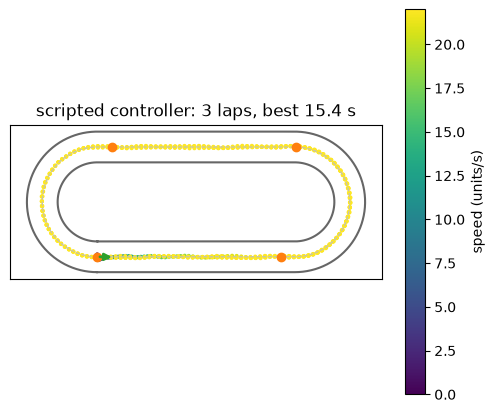

laps completed: 3, best lap: 15.4 s


In [5]:
def scripted_policy(obs):
    left, front, right, v = obs[:, 0], obs[:, 1], obs[:, 2], obs[:, 3]
    action = np.where(left > right, 0, 2)              # steer toward open space
    action = np.where(np.abs(left - right) < 0.05, 1, action)  # roughly centered: straight
    return np.where((front < 0.25) & (v > 0.35), 3, action)    # wall ahead at speed: brake


env = RacingEnv(track, config, n_envs=1, seed=3)
obs = env.reset()
xy, speed, best_lap, laps = [], [], np.inf, 0
for _ in range(600):
    obs, reward, done, info = env.step(scripted_policy(obs))
    xy.append(env.state[0, :2].copy())
    speed.append(env.state[0, 3])
    if not np.isnan(info["last_lap_time"][0]):
        best_lap = min(best_lap, info["last_lap_time"][0])
    laps = max(laps, info["lap"][0])
    if done[0]:
        break
xy = np.array(xy)

fig, ax = plt.subplots(figsize=(6, 5))
draw_track(ax, track)
sc = ax.scatter(xy[:, 0], xy[:, 1], c=speed, s=4, cmap="viridis")
fig.colorbar(sc, ax=ax, label="speed (units/s)")
ax.set_title(f"scripted controller: {laps} laps, best {best_lap:.1f} s")
plt.show()
print(f"laps completed: {laps}, best lap: {best_lap:.1f} s")

Three clean laps from an if-statement — so the task is *solvable* from this
observation. But the scripted controller wastes time wobbling between the side
rays and brakes conservatively. The interesting question is whether a learner
can do better, and how *small* that learner can be.

**Next:** [02 — Q-learning from scratch](02_q_learning_from_scratch.ipynb)
trains a tiny neural network to drive with exactly this observation and
reward.